In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [40]:
df=pd.read_csv("health dataset.csv")
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25,Normal,100,5.7,No,No,Healthy,Regular,No
1,55,Female,30,High,120,6.4,Yes,Yes,Poor,No,Yes
2,65,Male,35,High,140,7.1,Yes,Yes,Poor,No,Yes
3,75,Female,40,High,160,7.8,Yes,Yes,Poor,No,Yes
4,40,Male,20,Normal,80,5.0,No,No,Healthy,Regular,No


Checking whether there are null values.

In [41]:
print("Null values:")
df.isnull().sum()

Null values:


Age                           0
Gender                        0
BMI                           0
Blood Pressure                0
FBS                           0
HbA1c                         0
Family History of Diabetes    0
Smoking                       0
Diet                          0
Exercise                      0
Diagnosis                     0
dtype: int64

In [42]:
df.nunique()

Age                           35
Gender                         2
BMI                           34
Blood Pressure                 3
FBS                           11
HbA1c                         11
Family History of Diabetes     2
Smoking                        2
Diet                           2
Exercise                       2
Diagnosis                      2
dtype: int64

We can see that columns like Gender, Family History of Diabetes, Smoking, Diet, Exercise,Diagnosis can be easily transformed into binary values so that our model can process the data.

In [43]:
df["Gender"]=df["Gender"].map({"Male": 0, "Female": 1})

yes_no={"No":0, "Yes": 1}
for col in ["Diagnosis", "Smoking","Family History of Diabetes" ]:
    df[col]=df[col].map(yes_no)

df.head() #checking values

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,0,25,Normal,100,5.7,0,0,Healthy,Regular,0
1,55,1,30,High,120,6.4,1,1,Poor,No,1
2,65,0,35,High,140,7.1,1,1,Poor,No,1
3,75,1,40,High,160,7.8,1,1,Poor,No,1
4,40,0,20,Normal,80,5.0,0,0,Healthy,Regular,0


In [44]:
df["Diet"]=(df["Diet"]=="Healthy").astype(int)
df["Exercise"]=(df["Exercise"]=="Regular").astype(int)
df.head() #also checking

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,0,25,Normal,100,5.7,0,0,1,1,0
1,55,1,30,High,120,6.4,1,1,0,0,1
2,65,0,35,High,140,7.1,1,1,0,0,1
3,75,1,40,High,160,7.8,1,1,0,0,1
4,40,0,20,Normal,80,5.0,0,0,1,1,0


When it comes to Blood Pressure, it had to be dealt with One Hot Encoder. It could not be done with the solutions we used with smoking or diagnosis, because the model should not interpret as a scale (like the blood pressure is 2 or 1).

In [45]:
enc=OneHotEncoder(sparse_output=False)
data=enc.fit_transform(df[["Blood Pressure"]]) #2D format 
col_names=enc.get_feature_names_out(["Blood Pressure"])

data_fr_bp=pd.DataFrame(data, columns=col_names, index=df.index)
df=pd.concat([df.drop('Blood Pressure', axis=1), data_fr_bp], axis=1)
df

,Age,Gender,BMI,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis,Blood Pressure_High,Blood Pressure_Low,Blood Pressure_Normal
0,45,0,25,100,5.7,0,0,1,1,0,0.0,0.0,1.0
1,55,1,30,120,6.4,1,1,0,0,1,1.0,0.0,0.0
2,65,0,35,140,7.1,1,1,0,0,1,1.0,0.0,0.0
3,75,1,40,160,7.8,1,1,0,0,1,1.0,0.0,0.0
4,40,0,20,80,5.0,0,0,1,1,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,17,1,15,100,5.7,0,1,0,0,1,0.0,0.0,1.0
124,22,0,19,120,6.4,0,1,0,0,1,0.0,0.0,1.0
125,27,1,24,140,7.1,0,1,0,0,1,1.0,0.0,0.0
126,32,0,29,160,7.8,0,1,0,0,1,1.0,0.0,0.0


We can now see if the data is balanced.

In [46]:
df["Diagnosis"].value_counts()

Diagnosis
0    97
1    31
Name: count, dtype: int64

It is not, so we should split the data into train and test frames and then scale it.

In [58]:
y=df["Diagnosis"]
X=df.drop(columns="Diagnosis")

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

It is the classification problem so the Logistic Regression is used.

In [61]:
model=LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)
pred=model.predict(X_test_scaled)


In [55]:
cnf_matrix = metrics.confusion_matrix(y_test, pred)
cnf_matrix

array([[20,  0],
       [ 0,  6]])

It is strange that the model is too good, it could mean that some of the columns are corelating with Diagnosis. There are no False Positive nor False Negative values.

In [70]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Accuracy Baseline:" , acc_baseline.round(2))

Accuracy Baseline: 0.75


However the accuracy baseline is ok.

I also tried to visualize it with heatmap to see if there is a strong correlation with diagnosis and other columns.

Text(0.5, 1.0, 'Correlation Matrix')

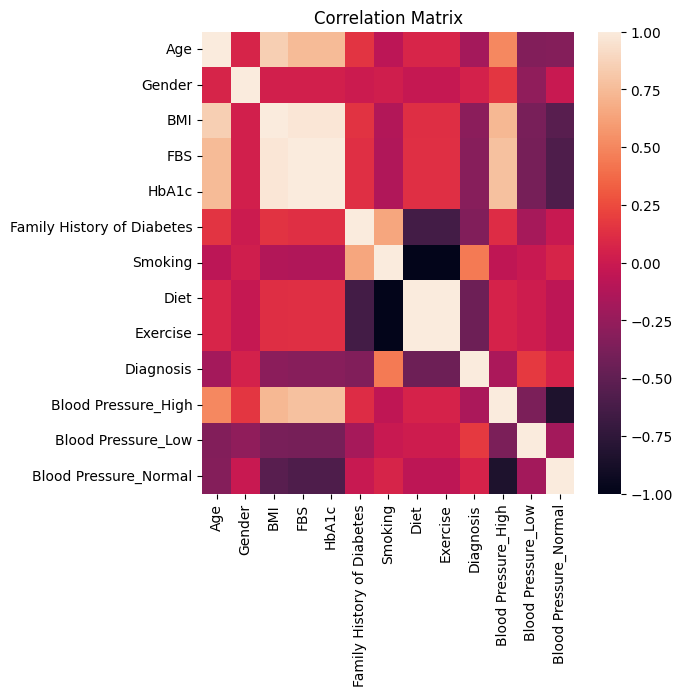

In [71]:
plt.figure(figsize=(6,6))
data_corr=df.corr()
sns.heatmap(data_corr)
plt.title("Correlation Matrix")

It seems that Diet and Exercise are in storng negative correlation with Smoking. The data set could be too simple to train that model.